In [2]:
import pandas as pd
df = pd.read_csv("D:/latihan/parfum/ebay_mens_perfume.csv")

In [3]:
df.head()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
0,Dior,Christian Dior Sauvage Men's EDP 3.4 oz Fragra...,Eau de Parfum,84.99,US $84.99/ea,10.0,More than 10 available / 116 sold,116.0,"May 24, 2024 10:03:04 PDT","Allen Park, Michigan, United States"
1,AS SHOW,A-v-entus Eau de Parfum 3.3 oz 100ML Millesime...,Eau de Parfum,109.99,US $109.99,8.0,8 available / 48 sold,48.0,"May 23, 2024 23:07:49 PDT","Atlanta, Georgia, Canada"
2,Unbranded,HOGO BOSS cologne For Men 3.4 oz,Eau de Toilette,100.00,US $100.00,10.0,More than 10 available / 27 sold,27.0,"May 22, 2024 21:55:43 PDT","Dearborn, Michigan, United States"
3,Giorgio Armani,Acqua Di Gio by Giorgio Armani 6.7 Fl oz Eau D...,Eau de Toilette,44.99,US $44.99/ea,2.0,2 available / 159 sold,159.0,"May 24, 2024 03:30:43 PDT","Reinholds, Pennsylvania, United States"
4,Lattafa,Lattafa Men's Hayaati Al Maleky EDP Spray 3.4 ...,Fragrances,16.91,US $16.91,NaN,Limited quantity available / 156 sold,156.0,"May 24, 2024 07:56:25 PDT","Brooklyn, New York, United States"


In [4]:
df.tail()

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation
995,GUESS,Guess 1981 by Guess cologne for men EDT 3.3 / ...,Eau de Toilette,20.28,US $20.28/ea,45.0,"45 available / 1,613 sold",1613.0,"May 24, 2024 08:14:07 PDT","Dallas, Texas, United States"
996,Armaf,Club de Nuit Intense by Armaf cologne for men ...,Eau de Toilette,30.58,US $30.58,10.0,More than 10 available / 31 sold,31.0,"May 23, 2024 08:39:30 PDT",United States
997,Paco Rabanne,Invictus by Paco Rabanne for Men EDT Spray 3.4...,Eau de Toilette,39.99,US $39.99/ea,2.0,2 available / 305 sold,305.0,"May 23, 2024 15:27:18 PDT","Jamaica, New York, United States"
998,Lomani,"Lomani EDT Cologne 3.4 oz Men - Authentic, Bra...",Eau de Toilette,9.99,US $9.99/ea,2.0,2 available / 22 sold,22.0,"May 20, 2024 13:20:54 PDT","Lincoln Park, Michigan, United States"
999,Estee Lauder,Beyond Paradise by Estee Lauder for Men Cologn...,Cologne spray,17.49,US $17.49/ea,10.0,More than 10 available / 24 sold,24.0,"Feb 28, 2024 07:27:01 PST","Keyport, New Jersey, United States"


In [6]:
df.columns

Index(['brand', 'title', 'type', 'price', 'priceWithCurrency', 'available',
       'availableText', 'sold', 'lastUpdated', 'itemLocation'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              999 non-null    object 
 1   title              1000 non-null   object 
 2   type               997 non-null    object 
 3   price              1000 non-null   float64
 4   priceWithCurrency  1000 non-null   object 
 5   available          889 non-null    float64
 6   availableText      997 non-null    object 
 7   sold               994 non-null    float64
 8   lastUpdated        947 non-null    object 
 9   itemLocation       1000 non-null   object 
dtypes: float64(3), object(7)
memory usage: 78.3+ KB


In [8]:
df.describe()

,price,available,sold
count,1000.000000,889.000000,994.000000
mean,46.481200,20.046119,766.266600
std,35.527862,61.547985,3200.971733
min,3.000000,2.000000,1.000000
25%,22.990000,5.000000,14.000000
50%,35.710000,10.000000,49.500000
75%,59.000000,10.000000,320.500000
max,259.090000,842.000000,54052.000000


In [10]:
# cek missing value
df.isnull().sum()

brand                  1
title                  0
type                   3
price                  0
priceWithCurrency      0
available            111
availableText          3
sold                   6
lastUpdated           53
itemLocation           0
dtype: int64

In [ ]:
# cek apakah ada duplikat dan berapa jumlahnya
df.duplicated().sum()

0

In [12]:
df.shape

(1000, 10)

In [ ]:
#hitung jumlah nilai unik
df.nunique()

brand                246
title                966
type                  63
price                601
priceWithCurrency    685
available             89
availableText        758
sold                 428
lastUpdated          933
itemLocation         276
dtype: int64

# Handle Missing value
**informasi kolom yang terdapat missing value dan jumlahnya:**
- brand                  1
- title                  0
- type                   3
- price                  0
- priceWithCurrency      0
- available            111
- availableText          3
- sold                   6
- lastUpdated           53
- itemLocation           0

In [ ]:
# ketersediaan yang Nan kita treat sebagai stok kosong yang berrti produk sudah habis / sedang tidak tersedia
df['available'] = df['available'].fillna(0)

In [16]:
# tejual yang Nan kita anggap tidak ada yang terjual
df['sold'] = df['sold'].fillna(0)

In [17]:
# brand dan type kita anggap tidak diketahui
df['brand'] = df['brand'].fillna('Unknown')
df['type'] = df['type'].fillna('Unknown')

In [ ]:
# mengubah kolom lastUpdated menjadi tipe tanggal (datetime)
df['lastUpdated'] = pd.to_datetime(df['lastUpdated'], errors='coerce')

c:\Users\jomba\Anaconda\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname PDT identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "
c:\Users\jomba\Anaconda\Lib\site-packages\dateutil\parser\_parser.py:1207: UnknownTimezoneWarning: tzname PST identified but not understood.  Pass `tzinfos` argument in order to correctly return a timezone-aware datetime.  In a future version, this will raise an exception.
  warnings.warn("tzname {tzname} identified but not understood.  "


In [19]:
# isi availabletext dengan format "{available} available / {sold} sold"
df['availableText'] = df['availableText'].fillna(
    df['available'].astype(int).astype(str) + ' available / ' + 
    df['sold'].astype(int).astype(str) + ' sold'
)

In [20]:
df.isnull().sum()

brand                 0
title                 0
type                  0
price                 0
priceWithCurrency     0
available             0
availableText         0
sold                  0
lastUpdated          53
itemLocation          0
dtype: int64

In [21]:
df['lastUpdated']

0     2024-05-24 10:03:04
1     2024-05-23 23:07:49
2     2024-05-22 21:55:43
3     2024-05-24 03:30:43
4     2024-05-24 07:56:25
              ...        
995   2024-05-24 08:14:07
996   2024-05-23 08:39:30
997   2024-05-23 15:27:18
998   2024-05-20 13:20:54
999   2024-02-28 07:27:01
Name: lastUpdated, Length: 1000, dtype: datetime64[ns]

In [22]:
#isi missing berdasarkan konteks asli
df['lastUpdated'] = df['lastUpdated'].ffill().bfill()

In [23]:
# sort untuk analisis waktu jika dibutuhkan
df = df.sort_values('lastUpdated')

In [24]:
df.isnull().sum()

brand                0
title                0
type                 0
price                0
priceWithCurrency    0
available            0
availableText        0
sold                 0
lastUpdated          0
itemLocation         0
dtype: int64

# Basic Eksplorasi

In [ ]:
# Top 10 Brand
# cek brand paling dominan di market
df['brand'].value_counts().head(10)

Giorgio Armani        60
Paco Rabanne          45
Ralph Lauren          41
Unbranded             39
Armaf                 34
Dolce&Gabbana         32
Yves Saint Laurent    30
Versace               20
Calvin Klein          17
Cologne               16
Name: brand, dtype: int64

In [ ]:
# Distribusi harga
# harga rata-rata parfum
# market ini cenderung low / mid / premium?
df['price'].describe()

count    1000.000000
mean       46.481200
std        35.527862
min         3.000000
25%        22.990000
50%        35.710000
75%        59.000000
max       259.090000
Name: price, dtype: float64

In [27]:
# Lokasi Penjualan
# Kota dengan supply parfum terbanyak
df['itemLocation'].value_counts().head()

Dallas, Texas, United States             126
Hackensack, New Jersey, United States    105
Brooklyn, New York, United States         76
Miami, Florida, United States             41
Edison, New Jersey, United States         35
Name: itemLocation, dtype: int64

# Insight Bisnis

In [28]:
# Brand vs Penjualan
# melihat brand mana yang paling laku
df.groupby('brand')['sold'].sum().sort_values(ascending=False).head(10)

brand
Calvin Klein     97572.0
Versace          96519.0
Davidoff         54944.0
Azzaro           38305.0
Armaf            24282.0
Kenneth Cole     23716.0
Paco Rabanne     21579.0
Liz Claiborne    21341.0
Burberry         19286.0
2nd To None      18882.0
Name: sold, dtype: float64

In [29]:
# Price sensitivity
# kalau negatif → makin mahal makin sedikit terjual
# kalau lemah → harga bukan faktor utama
df[['price','sold']].corr()

,price,sold
price,1.000000,-0.084688
sold,-0.084688,1.000000


In [ ]:
# Segmentasi Harga
# segmen mana paling laku?
# cocok buat positioning bisnis

df['price_category'] = pd.cut(df['price'],
                             bins=[0, 100000, 300000, 1000000],
                             labels=['Murah','Menengah','Mahal'])

df.groupby('price_category')['sold'].mean()

price_category
Murah       761.669
Menengah        NaN
Mahal           NaN
Name: sold, dtype: float64

In [31]:
# supply-demand
# kalau demand tinggi tapi stock kecil berrti ada peluang bisnis
df[['available','sold']].corr()

,available,sold
available,1.000000,0.089208
sold,0.089208,1.000000


In [32]:
# Lokasi vs penjualan
# kota mana paling “panas” dan bisa jadi target market
df.groupby('itemLocation')['sold'].sum().sort_values(ascending=False)

itemLocation
Hackensack, New Jersey, United States    422755.0
Dallas, Texas, United States             221711.0
LaGrange, Georgia, United States          18882.0
Houston, Texas, United States             13553.0
Katy, Texas, United States                 9071.0
                                           ...   
Graham, Washington, United States             1.0
Ottawa, Canada                                1.0
Lakewood, California, United States           0.0
St. George, Utah, United States               0.0
Paterson, New Jersey, United States           0.0
Name: sold, Length: 276, dtype: float64

In [33]:
# Type parfum
# mana yang paling laku EDT/EDP/???
df['type'].value_counts()

Eau de Toilette                                          444
Eau de Parfum                                            285
Eau de Cologne                                            56
Perfume                                                   50
Fragrances                                                32
                                                        ... 
Deodorant                                                  1
Eau De Toilette, Eau De Parfum, Eau De Parfum Intense      1
Jo Malone Cologne Intense Spray                            1
Concentrated Uncut Pure Body Oil                           1
Eau de Toilette Intense                                    1
Name: type, Length: 64, dtype: int64

In [ ]:
# Revenue Estimation
# brand paling menghasilkan uang (bukan cuma laku)
df['revenue'] = df['price'] * df['sold']

In [38]:
top_brand = df.groupby('brand')['revenue'].sum().sort_values(ascending=False).head(10)
top_brand

brand
Versace               3542617.83
Calvin Klein          2492204.62
Azzaro                1673078.61
Davidoff              1570975.76
Paco Rabanne           972847.28
Yves Saint Laurent     928147.26
Armaf                  875738.65
Ralph Lauren           753028.32
Dolce&Gabbana          661678.23
Kenneth Cole           577829.82
Name: revenue, dtype: float64

<Axes: xlabel='brand'>

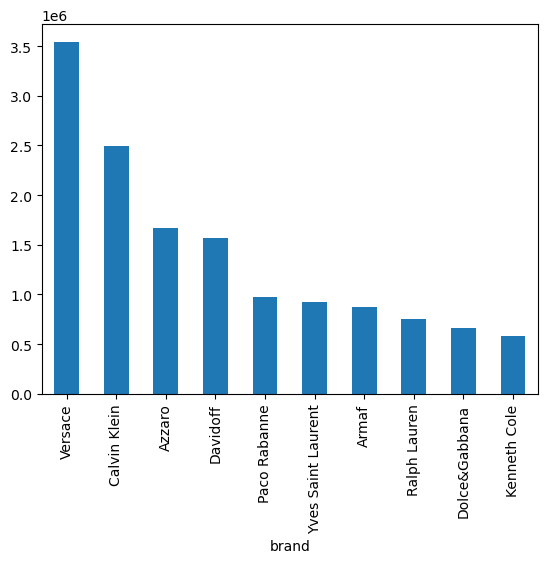

In [39]:
top_brand.plot(kind='bar')

In [36]:
#Best Product (High Demand + Affordable)
# produk “sweet spot” → cocok dijual ulang
df[(df['sold'] > df['sold'].quantile(0.75)) & 
   (df['price'] < df['price'].median())]

,brand,title,type,price,priceWithCurrency,available,availableText,sold,lastUpdated,itemLocation,price_category,revenue
934,Cologne,New 10x New Random Unique Men's Fragrance Colo...,Perfume,19.90,US $19.90,0.0,More than 10 lots available (10 items per lot)...,331.0,2023-11-21 08:32:55,"Stony Brook, New York, United States",Murah,6586.90
943,Dana,Women TABU by DANA 2.3 oz EDC Spray New In Box...,Eau de Cologne,14.99,US $14.99/ea,10.0,More than 10 available / 647 sold,647.0,2024-02-16 20:33:33,"Orlando, Florida, United States",Murah,9698.53
161,Karl Lagerfeld,Lagerfeld Classic 3.3 oz 100 ml EDT spray mens...,Eau de Toilette,16.91,US $16.91/ea,6.0,6 available / 825 sold,825.0,2024-03-04 18:12:48,"Edison, New Jersey, United States",Murah,13950.75
118,Dolce & Gabbana,D&G DOLCE & GABBANA LIGHT BLUE EAU INTENSE MEN...,Eau de Parfum,11.00,US $11.00,10.0,More than 10 available / 702 sold,702.0,2024-04-05 00:52:00,"Albany, New York, United States",Murah,7722.00
297,Louis Vuitton,Louis Vuitton Ombre Nomade Eau De Parfum Sampl...,Eau de Parfum,22.95,US $22.95/ea,9.0,9 available / 647 sold,647.0,2024-04-21 21:21:42,"Pearland, Texas, United States",Murah,14848.65
...,...,...,...,...,...,...,...,...,...,...,...,...
708,Armaf,Le Parfait Pour Homme by Armaf Cologne For Men...,Eau de Parfum,19.41,US $19.41/ea,86.0,86 available / 501 sold,501.0,2024-05-24 10:13:10,"Dallas, Texas, United States",Murah,9724.41
182,Calvin Klein,Eternity Flame by Calvin Klein 3.4 oz EDT Colo...,Eau de Toilette,25.98,US $25.98/ea,10.0,"More than 10 available / 1,536 sold",1536.0,2024-05-24 10:18:05,"Hackensack, New Jersey, United States",Murah,39905.28
272,Lomani,AB SPIRIT MILLIONAIRE by Lomani men 3.3 oz 3.4...,Eau de Toilette,16.39,US $16.39/ea,31.0,"31 available / 1,630 sold",1630.0,2024-05-24 10:18:08,"Dallas, Texas, United States",Murah,26715.70
43,Givenchy,PI by Givenchy cologne for men EDT 3.3 / 3.4 o...,Eau de Toilette,34.72,US $34.72/ea,71.0,71 available / 627 sold,627.0,2024-05-24 10:20:09,"Dallas, Texas, United States",Murah,21769.44


In [40]:
#Revenue per produk (bukan total brand)
top_produk = df.sort_values('revenue', ascending=False)[['brand','title','price','sold','revenue']].head(10)
top_produk

,brand,title,price,sold,revenue
44,Azzaro,Chrome by Azzaro 6.7 / 6.8 oz EDT Cologne for ...,46.33,30655.0,1420246.15
81,Calvin Klein,Ck One by Calvin Klein Cologne Perfume Unisex ...,23.89,54052.0,1291302.28
184,Versace,Versace Eros by Gianni Versace 3.4 oz EDT Colo...,39.77,31718.0,1261424.86
642,Davidoff,Cool Water by Davidoff 4.2 oz EDT Cologne for ...,25.23,40130.0,1012479.90
188,Versace,Versace Pour Homme Signature by Versace 3.4 oz...,44.94,21310.0,957671.40
57,Versace,Versace Pour Homme Signature by Versace 3.4 oz...,36.88,19899.0,733875.12
76,Calvin Klein,OBSESSION by Calvin Klein 4.0 oz 4 MEN edt Col...,23.56,24048.0,566570.88
163,Davidoff,Cool Water by Davidoff Cologne for Men 6.7 / 6...,38.24,13549.0,518113.76
242,Paco Rabanne,1 Million by Paco Rabanne 3.4 oz EDT Cologne f...,47.99,8877.0,426007.23
826,HUGO BOSS,Hugo by Hugo Boss 6.7 oz EDT Cologne for Men B...,50.79,7506.0,381229.74


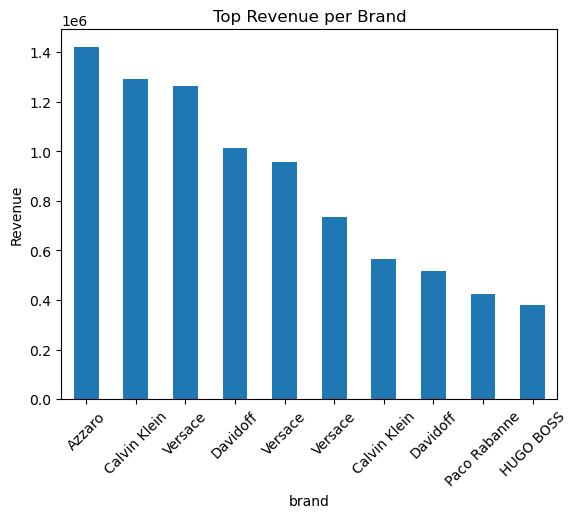

In [42]:
import matplotlib.pyplot as plt

top_produk.set_index('brand')['revenue'].plot(kind='bar')
plt.xticks(rotation=45)
plt.title('Top Revenue per Brand')
plt.ylabel('Revenue')
plt.show()